#**Biblioteca Keras**

 É uma biblioteca que facilita a construção e o treinamento de modelos de deep learning.

# *Dataset MNIST (biblioteca Keras)*

Base de dados de dígitos manuscritos. O MNIST têm 60000 imagens rotuladas para treinamento e 10000 para testes. O MNIST pode ser importado da biblioteca Keras para ser utilizado no Colab.

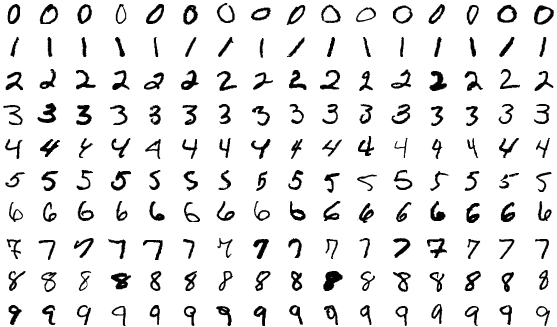



##**1 - Carregando as bibliotecas**##

In [1]:
from keras import datasets, models, layers, utils, backend, Sequential
import cv2, random, os
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(100)
random.seed(100)
utils.set_random_seed(100)
os.environ['PYTHONHASHSEED'] = str(100)

##**2 - Formantando os dados de entrada**

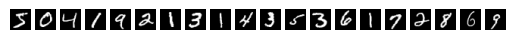

Categorização normal: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
Categorização transformada: [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [10]:
# Define o formato dos dados de imagem como 'channels_last', ou seja,
# a dimensão dos canais (ex: RGB) vem por último: (altura, largura, canais)
backend.set_image_data_format('channels_last')

# Carrega o dataset MNIST já dividido em treino e validação:
# x = imagens (28x28 pixels), y = rótulos (dígitos de 0 a 9)
(x_train, y_train), (x_val, y_val) = datasets.mnist.load_data()

# Visualiza as primeiras 20 imagens do conjunto de treino
for i, image in enumerate(x_train[:20]):
    # Cria um subplot para cada imagem na mesma linha
    plt.subplot(1, len(x_train[:20]), i + 1)
    
    # Exibe a imagem em escala de cinza invertida (dígitos escuros em fundo claro)
    plt.imshow(image, cmap='gray')
    
    # Remove os eixos para uma visualização mais limpa
    plt.axis('off')

plt.show()

# Normaliza os pixels de [0, 255] para [0.0, 1.0]
# Isso melhora a convergência do modelo durante o treinamento
x_train = x_train.astype('float32') / 255.0
x_val   = x_val.astype('float32') / 255.0

# Exibe os rótulos originais (números inteiros de 0 a 9)
print(f'Categorização normal: {y_val[:20]}')

# Converte os rótulos para one-hot encoding
# Ex: o dígito 3 vira [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# Isso é necessário para usar a função de perda categorical_crossentropy
y_train = utils.to_categorical(y_train)
y_val   = utils.to_categorical(y_val)

# Exibe os rótulos após a transformação para conferir o resultado
print(f'Categorização transformada: {y_val[:20]}')

##**3 - Contruindo o modelo da rede neural**

In [3]:
# Cria um modelo sequencial: as camadas são empilhadas linearmente,
# uma após a outra, sem ramificações
model = Sequential()

# --- Entrada ---
# shape=(28, 28, 1)
#   → 28x28: dimensões da imagem em pixels
#   → 1: número de canais (1 = escala de cinza; seria 3 para RGB)
model.add(layers.Input(shape=(28, 28, 1)))

# --- Camada Convolucional ---
# 30          → número de filtros (cada um aprende um padrão diferente: bordas, curvas, etc.)
# kernel_size → tamanho de cada filtro; (3,3) = janela 3x3 pixels que "varre" a imagem
# strides     → passo do filtro ao se mover; (1,1) = avança 1 pixel por vez (máximo detalhe)
# activation  → 'relu' zerifica valores negativos, introduzindo não-linearidade ao modelo
model.add(layers.Conv2D(30, kernel_size=(3, 3), strides=(1, 1), activation='relu'))

# --- Pooling ---
# pool_size=(2, 2) → janela de redução 2x2; pega o valor máximo de cada bloco
# Resultado: o mapa de características é reduzido à metade (ex: 26x26 → 13x13)
# Mantém os padrões mais fortes e descarta informações espaciais redundantes
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# --- Dropout ---
# 0.3 → fração de neurônios desativados aleatoriamente a cada passo de treino
# Valores comuns: entre 0.2 e 0.5
# Muito alto (ex: 0.8): modelo aprende pouco → underfitting
# Muito baixo (ex: 0.05): regularização insuficiente → overfitting
model.add(layers.Dropout(0.3))

# --- Flatten ---
# Sem parâmetros configuráveis
# Achata o tensor 3D (altura, largura, filtros) em vetor 1D
# Ex: (13, 13, 30) → vetor de 5070 valores
# Necessário para conectar às camadas Dense que esperam entrada unidimensional
model.add(layers.Flatten())

# --- Camadas Densas (Fully Connected) ---
# 128        → número de neurônios; quanto mais neurônios, maior a capacidade de aprender
# activation → 'relu' mantém a não-linearidade entre camadas densas
# Aprende combinações abstratas dos padrões detectados pela convolução
model.add(layers.Dense(128, activation='relu'))

# 64 neurônios: camada intermediária que comprime a representação antes da saída
# Usar menos neurônios que a camada anterior cria um "funil" de abstração
model.add(layers.Dense(64, activation='relu'))

# --- Camada de Saída ---
# 10          → um neurônio por classe (dígitos 0 a 9)
# activation  → 'softmax' converte os valores brutos em probabilidades que somam 1.0
#               Ex: [0.02, 0.01, 0.90, 0.01, ...] → modelo prevê o dígito 2 com 90%
# name        → rótulo opcional para identificar a camada (útil ao inspecionar o modelo)
model.add(layers.Dense(10, activation='softmax', name='Output'))

##**4 - Executando o treinamento**

In [26]:
# --- Compilação do modelo ---
# Define como o modelo vai aprender antes de iniciar o treino

# loss='categorical_crossentropy'
#   → Função de perda usada quando há múltiplas classes com one-hot encoding
#   → Mede o quão erradas estão as previsões do modelo
#   → Quanto menor o valor, mais próximas as previsões estão do gabarito
#   → Alternativa comum: 'sparse_categorical_crossentropy' (quando os rótulos são inteiros, não precisa do one-hot transformado)

# optimizer='adam'
#   → Algoritmo que ajusta os pesos da rede para minimizar a função de perda
#   → Adam (Adaptive Moment Estimation) combina duas técnicas:
#       - Momentum: acelera o aprendizado na direção certa
#       - RMSProp: ajusta a taxa de aprendizado individualmente por peso
#   → É o otimizador mais usado no dia a dia por ser robusto e rápido
#   → Alternativas: 'sgd' (mais simples), 'rmsprop', 'adagrad'

# metrics=['accuracy']
#   → Métrica exibida durante o treino para monitorar o desempenho
#   → Accuracy = proporção de previsões corretas (ex: 0.97 = 97% de acerto)
#   → Não influencia o treino, serve apenas como indicador de acompanhamento
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- Treinamento do modelo ---
# x_train, y_train    → dados e rótulos usados para ajustar os pesos da rede
#
# epochs=10           → número de vezes que o modelo percorre todo o conjunto de treino
#                     → Poucas épocas: modelo não aprende o suficiente (underfitting)
#                     → Muitas épocas: modelo pode memorizar os dados (overfitting)
#
# batch_size=128      → quantas amostras são processadas antes de atualizar os pesos
#                     → Batch pequeno (ex: 32): atualizações mais frequentes, treino mais lento
#                     → Batch grande (ex: 512): atualizações menos frequentes, treino mais rápido
#                     → 128 é um valor equilibrado para a maioria dos casos
#
# validation_data=... → conjunto separado (x_val, y_val) usado para avaliar o modelo
#                       ao final de cada época, sem influenciar o ajuste dos pesos
#                     → Permite detectar overfitting: se a acurácia de treino sobe mas a
#                       de validação cai, o modelo está memorizando os dados de treino
model.fit(x_train, y_train, epochs=3, batch_size=200, validation_data=(x_val, y_val))

Epoch 1/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9828 - loss: 0.0559 - val_accuracy: 0.9835 - val_loss: 0.0496
Epoch 2/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9863 - loss: 0.0442 - val_accuracy: 0.9874 - val_loss: 0.0407
Epoch 3/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9884 - loss: 0.0358 - val_accuracy: 0.9881 - val_loss: 0.0366


##**5 - Testando a rede treinada com uma imagem que não pertence ao dataset**

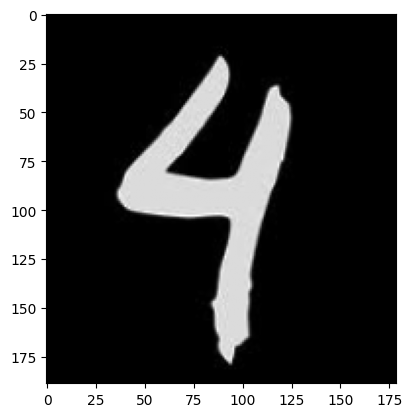

In [27]:
# Carrega a imagem 'Digito.png' em escala de cinza
# O resultado é uma matriz 2D com valores de 0 (preto) a 255 (branco)
pred_img = cv2.imread('Digito.png', cv2.IMREAD_GRAYSCALE)

# Inverte os valores de cada pixel: novo_valor = 255 - valor_original
# Necessário porque o MNIST foi treinado com dígitos BRANCOS em fundo PRETO
# Se a sua imagem tiver dígito PRETO em fundo BRANCO (como uma foto comum),
# o modelo não reconhecerá corretamente sem essa inversão
pred_img_reversed = cv2.bitwise_not(pred_img)

# Exibe a imagem invertida para conferir visualmente antes de passar ao modelo
# cmap='gray' garante que a exibição use tons de cinza (e não cores falsas)
plt.imshow(pred_img_reversed, cmap='gray')

In [32]:
# Verifica se a imagem já está no tamanho esperado pelo modelo (28x28 pixels)
# Imagens capturadas do mundo real geralmente têm tamanhos diferentes
# ex: uma foto tirada do celular pode ter 1080x1920 pixels
if pred_img_reversed.shape != (28, 28):
    # Redimensiona para 28x28 — tamanho exato que o modelo foi treinado para receber
    # cv2.resize recebe (largura, altura), por isso (28, 28) e não (28, 28, 1)
    # O algoritmo padrão de interpolação (INTER_LINEAR) é suficiente para esse caso
    pred_img_reversed = cv2.resize(pred_img_reversed, (28, 28))

# Ajusta o shape e o tipo da imagem para o formato esperado pelo modelo
# .reshape(1, 28, 28, 1):
#   → 1    : batch size (estamos prevendo 1 imagem por vez)
#   → 28   : altura em pixels
#   → 28   : largura em pixels
#   → 1    : canal (1 = escala de cinza; seria 3 para RGB)
# .astype('float32'):
#   → converte os pixels de inteiros (0–255) para float, necessário para a divisão abaixo
pred_img_reshaped = pred_img_reversed.reshape(1, 28, 28, 1).astype('float32') / 255.0

# Passa a imagem pelo modelo e obtém as probabilidades para cada classe (0 a 9)
# O resultado é um array de shape (1, 10) — 10 probabilidades que somam 1.0
# ex: [[0.01, 0.02, 0.95, 0.01, ...]] → modelo acredita que é o dígito 2 com 95%
prediction = model.predict(pred_img_reshaped)

# Exibe o array completo de probabilidades brutas
# Para ver apenas o dígito previsto, use: print(prediction.argmax())
print(f'Previsão do modelo: {prediction}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Previsão do modelo: [[2.4394346e-08 2.4886056e-05 2.1345477e-06 4.0083449e-07 9.9848962e-01
  1.4110615e-06 1.4281656e-08 2.4125582e-06 3.2736841e-04 1.1516429e-03]]


In [ ]:
# np.argmax retorna o índice do maior valor em um array
# axis=-1 → procura o máximo no último eixo (as 10 probabilidades de cada previsão)
# ex: prediction = [[0.01, 0.02, 0.95, 0.00, 0.01, 0.00, 0.00, 0.00, 0.01, 0.00]]
#     np.argmax   →  [2]  (índice 2 tem o maior valor: 0.95)
# Como o MNIST mapeia índices diretamente aos dígitos, índice 2 = dígito "2"
prediction_argmax = np.argmax(prediction, axis=-1)

# prediction_argmax é um array de shape (1,) — um resultado por imagem do batch
# [0] acessa o primeiro (e único) resultado, retornando um inteiro simples
# ex: array([2]) → 2
print(f'Melhor classe prevista: {prediction_argmax[0]}')

Melhor classe prevista: 4
